<h1>Section 1</h1>

<h3>Partie 1 :</h3><h4>1. Description des données</h4>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
df = pd.read_csv("Data_M2_TP1_MKokou/obesity_data.csv")

In [2]:
print(df.shape)

(1000, 7)


In [3]:
print(df.head(5))

   Age  Gender      Height     Weight        BMI  PhysicalActivityLevel  \
0   56    Male  173.575262  71.982051  23.891783                      4   
1   69    Male  164.127306  89.959256  33.395209                      2   
2   46  Female  168.072202  72.930629  25.817737                      4   
3   32    Male  168.459633  84.886912  29.912247                      3   
4   60    Male  183.568568  69.038945  20.487903                      3   

  ObesityCategory  
0   Normal weight  
1           Obese  
2      Overweight  
3      Overweight  
4   Normal weight  


<p>Le BMI = poids / taille² (taille en m). L'OMS s'en sert pour classer : moins de 18,5 Underweight, 18,5 à 25 Normal weight, 25 à 30 Overweight, 30 et plus Obese.</p>
<p>On a 1000 individus et 7 variables : Age et PhysicalActivityLevel (entiers, de 1 à 4 pour l'activité), Gender (binaire mais en chaîne de caractères), Height (cm), Weight (kg) et BMI (réels), et ObesityCategory (4 classes, ordonnées).</p>

In [4]:
print(df.isna().sum())
print("Doublons :", df.duplicated().sum())

Age                      0
Gender                   0
Height                   0
Weight                   0
BMI                      0
PhysicalActivityLevel    0
ObesityCategory          0
dtype: int64
Doublons : 0


<p>On n'a pas de valeur manquante ni de doublon.</p>

In [5]:
print(df.describe().round(2).T)
print()
print(df["Gender"].value_counts())
print()
print(df["PhysicalActivityLevel"].value_counts().sort_index())

                        count    mean    std     min     25%     50%     75%  \
Age                    1000.0   49.86  18.11   18.00   35.00   50.00   66.00   
Height                 1000.0  170.05  10.31  136.12  163.51  169.80  177.35   
Weight                 1000.0   71.21  15.51   26.07   61.13   71.93   81.13   
BMI                    1000.0   24.89   6.19    8.47   20.92   24.70   28.73   
PhysicalActivityLevel  1000.0    2.53   1.12    1.00    2.00    3.00    4.00   

                          max  
Age                     79.00  
Height                 201.42  
Weight                 118.91  
BMI                     50.79  
PhysicalActivityLevel    4.00  

Gender
Male      523
Female    477
Name: count, dtype: int64

PhysicalActivityLevel
1    239
2    247
3    255
4    259
Name: count, dtype: int64


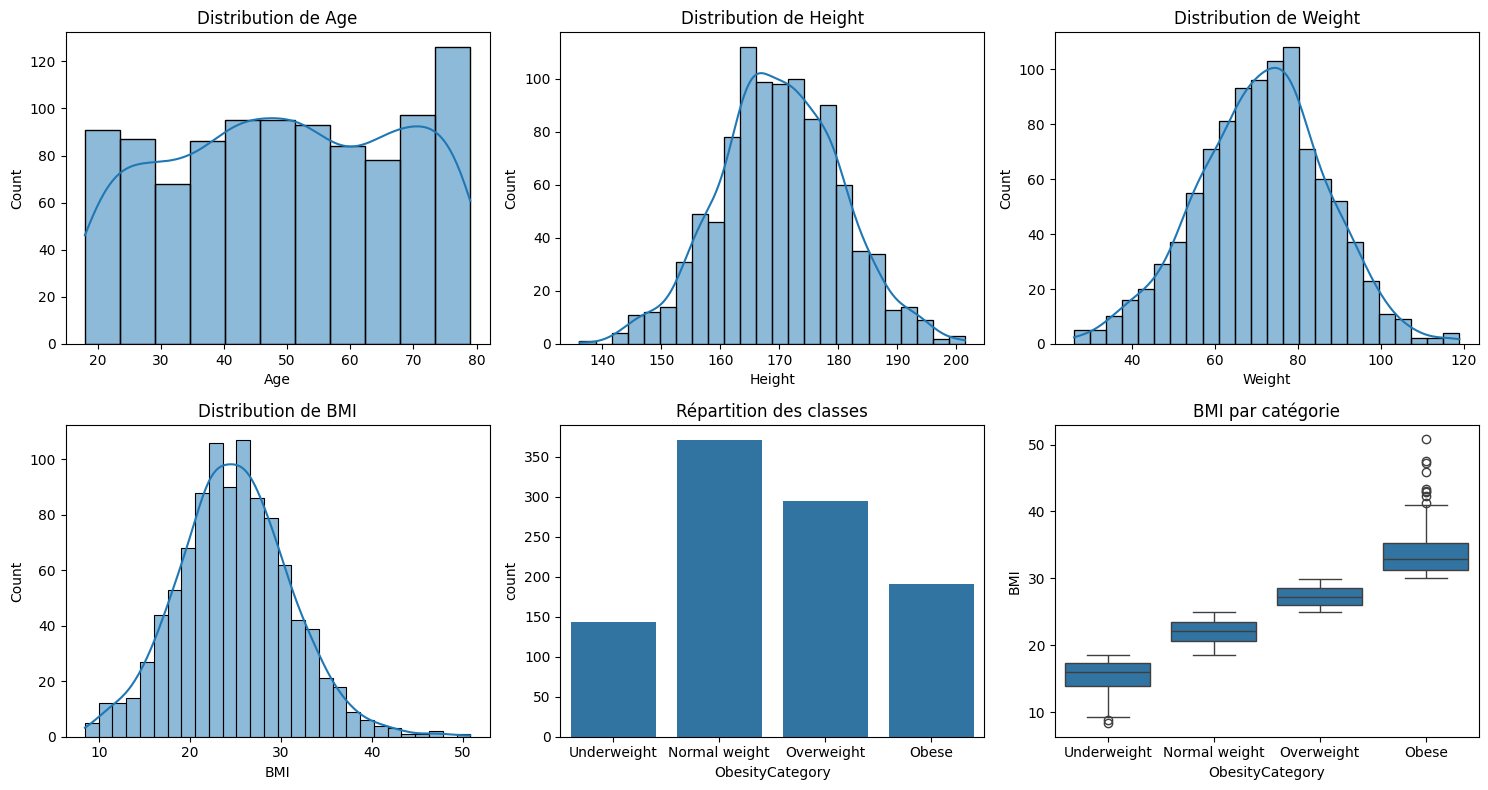

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel()[:4], ["Age", "Height", "Weight", "BMI"]):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(f"Distribution de {col}")
order = ["Underweight", "Normal weight", "Overweight", "Obese"]
sns.countplot(data=df, x="ObesityCategory", order=order, ax=axes[1, 1])
axes[1, 1].set_title("Répartition des classes")
sns.boxplot(data=df, x="ObesityCategory", y="BMI", order=order, ax=axes[1, 2])
axes[1, 2].set_title("BMI par catégorie")
plt.tight_layout()
plt.show()

In [7]:
# Vérification de la formule du BMI (Height en cm) et des seuils par catégorie
bmi_calc = df["Weight"] / (df["Height"] / 100) ** 2
print("Écart max |BMI - Weight/Height²| :", (bmi_calc - df["BMI"]).abs().max().round(6))
print()
print(df.groupby("ObesityCategory")["BMI"].agg(["min", "max"]).loc[order].round(2))

Écart max |BMI - Weight/Height²| : 0.0

                   min    max
ObesityCategory              
Underweight       8.47  18.49
Normal weight    18.51  24.97
Overweight       25.00  29.98
Obese            30.01  50.79


<p>Les valeurs sont plausibles (âge de 18 à 79 ans, taille de 136 à 201 cm) et les sexes sont équilibrés (523 H / 477 F). Le BMI est bien égal à Weight / Height².</p>
<p>Point important : les plages de BMI des 4 classes ne se chevauchent pas et suivent exactement les seuils de l'OMS. La cible est donc calculée directement à partir du BMI, on en reparle en Q7 et Q10.</p>
<p>Les classes sont un peu déséquilibrées (Normal 37 %, Overweight 29,5 %, Obese 19 %, Underweight 14 %).</p>

<h3>Partie 2 :</h3><h4>2. Type d'apprentissage</h4>

<p>On fait de l'apprentissage supervisé parce qu'on a une variable cible déjà étiquetée (ObesityCategory) : le modèle apprend à la prédire à partir des autres variables.</p>

<h4>3. Tâche choisie</h4>
<p>La cible a 4 classes, donc c'est de la classification multiclasse (pas de la régression). Les classes sont aussi ordonnées : confondre Normal et Overweight est moins grave que confondre Normal et Obese.</p>

<h4>4. Métriques d'évaluation</h4>
<p>Accuracy = bonnes prédictions / total. Précision = TP / (TP + FP) : quand le modèle dit "Obese", a-t-il raison ? Recall = TP / (TP + FN) : parmi les vrais obèses, combien on en trouve ? F1 = moyenne harmonique des deux.</p>
<p>Ici les classes sont déséquilibrées, donc l'accuracy seule ne suffit pas : un modèle qui répondrait toujours "Normal weight" aurait déjà 37 %. Dans un cas plus extrême (95 % de non-obèses), un modèle qui ne détecte jamais l'obésité aurait 95 % d'accuracy avec un recall de 0 %. L'accuracy est gonflée par la classe majoritaire.</p>
<p>On regarde donc précision, recall et F1 par classe, puis la moyenne macro (toutes les classes comptent pareil, même les petites). En santé, le recall est le plus important : rater un cas d'obésité est plus grave qu'une fausse alerte.</p>

<h4>5. Variable d'intérêt</h4>
<p>C'est ObesityCategory (4 classes : Underweight, Normal weight, Overweight, Obese).</p>

<h4>6. Variables explicatives</h4>
<p>Au départ : Age, Gender, Height, Weight, BMI et PhysicalActivityLevel. Après le prétraitement (Q7), il reste Age, Gender, BMI et PhysicalActivityLevel.</p>

<h3>Partie 3:</h3><h4>7. Preprocessing</h4>
<p>a. Pas de valeur manquante (vu en Partie 1).</p>
<p>b. Gender n'a que 2 valeurs, on la transforme en 0 (Male) et 1 (Female).</p>
<p>c. Height et Weight donnent la même information que BMI (BMI = Weight / Height²), donc on garde BMI et on supprime les deux autres.</p>
<p>Attention : la cible est calculée à partir du BMI, donc garder le BMI revient à donner la réponse au modèle (fuite de la cible). On le fait pour suivre l'énoncé, mais les scores ne montreront pas une vraie capacité de prédiction. Un complément plus bas refait l'exercice avec Height et Weight à la place du BMI.</p>
<p>d. Pas besoin de normaliser, les arbres n'en ont pas besoin.</p>

In [8]:
df_raw = df.copy()   # copie avant prétraitement (réutilisée pour le complément sans BMI)
df["Gender"] = df["Gender"].map({"Male": 0, "Female": 1})
df = df.drop(columns=["Height", "Weight"])

In [9]:
print(df.head(5))

   Age  Gender        BMI  PhysicalActivityLevel ObesityCategory
0   56       0  23.891783                      4   Normal weight
1   69       0  33.395209                      2           Obese
2   46       1  25.817737                      4      Overweight
3   32       0  29.912247                      3      Overweight
4   60       0  20.487903                      3   Normal weight


<h3>Partie 4:</h3><h4>8. Séparation train / test</h4>
<p>80 % train, 20 % test. On fixe random_state pour avoir toujours le même découpage, et stratify pour garder les mêmes proportions de classes dans les deux.</p>

In [10]:
from sklearn.model_selection import train_test_split

X = df[["Age", "Gender", "BMI", "PhysicalActivityLevel"]]  # Features
Y = df["ObesityCategory"]                                   # Target
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, train_size=0.8, test_size=0.2, random_state=SEED, stratify=Y
)

In [11]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((800, 4), (800,), (200, 4), (200,))

<h3>Partie 5:</h3><h4>9. Arbre de décision avec Scikit-learn</h4>
<p>Scikit-learn utilise CART (splits binaires avec un seuil, critère Gini par défaut). Ce n'est ni ID3 ni C4.5.</p>

In [12]:
from sklearn.tree import DecisionTreeClassifier

clf = DecisionTreeClassifier(random_state=SEED)   # hyperparamètres par défaut (criterion='gini')
model1 = clf.fit(X_train, y_train)

<h4>10. Évaluation de la capacité de généralisation</h4>

=== Model 1 (gini) ===
accuracy (train) : 1.0
accuracy (test)  : 1.0
precision macro  : 1.0
recall macro     : 1.0
F1 macro         : 1.0

               precision    recall  f1-score   support

Normal weight      1.000     1.000     1.000        74
        Obese      1.000     1.000     1.000        38
   Overweight      1.000     1.000     1.000        59
  Underweight      1.000     1.000     1.000        29

     accuracy                          1.000       200
    macro avg      1.000     1.000     1.000       200
 weighted avg      1.000     1.000     1.000       200



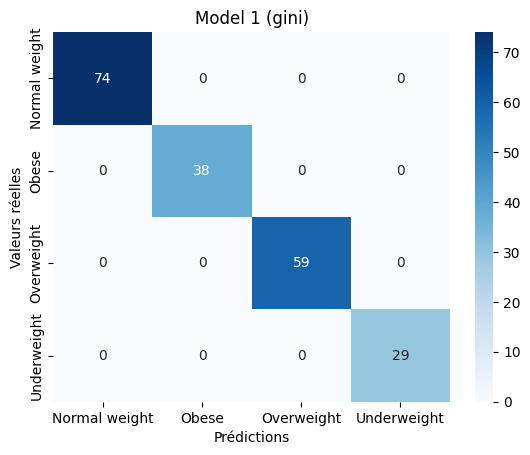

In [13]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

def evaluate(model, X_tr, y_tr, X_te, y_te, name="modèle"):
    """Affiche les métriques (train vs test) et la matrice de confusion."""
    y_pred = model.predict(X_te)
    print(f"=== {name} ===")
    print("accuracy (train) :", round(model.score(X_tr, y_tr), 4))
    print("accuracy (test)  :", round(accuracy_score(y_te, y_pred), 4))
    print("precision macro  :", round(precision_score(y_te, y_pred, average="macro"), 4))
    print("recall macro     :", round(recall_score(y_te, y_pred, average="macro"), 4))
    print("F1 macro         :", round(f1_score(y_te, y_pred, average="macro"), 4))
    print()
    print(classification_report(y_te, y_pred, digits=3))
    cm = confusion_matrix(y_te, y_pred, labels=model.classes_)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=model.classes_, yticklabels=model.classes_)
    plt.xlabel("Prédictions"); plt.ylabel("Valeurs réelles"); plt.title(name)
    plt.show()

evaluate(model1, X_train, y_train, X_test, y_test, "Model 1 (gini)")

<p>Toutes les métriques sont à 1,0 sur le test (avant, sans graine fixée, j'avais 0,99 : ça varie un peu selon le découpage). Ce n'est pas normal pour des données jamais vues, et c'est dû à la fuite de la cible : l'arbre ne fait que retrouver les seuils de l'OMS sur le BMI (18,5 / 25 / 30, voir Q14).</p>
<p>Train et test sont tous les deux à 1,0, donc pas de surapprentissage visible, mais seulement parce que le problème est trop facile. Les rares erreurs sur d'autres découpages viennent d'un BMI tout près d'un seuil.</p>

<h3>Partie 6:</h3><h4>11. Un autre critère de sélection avec le même algorithme</h4>
<p>On remplace Gini par l'entropie.</p>

In [14]:
clf1 = DecisionTreeClassifier(criterion="entropy", random_state=SEED)
model2 = clf1.fit(X_train, y_train)

<h4>12. Évaluation du Model 2</h4>

=== Model 2 (entropy) ===
accuracy (train) : 1.0
accuracy (test)  : 1.0
precision macro  : 1.0
recall macro     : 1.0
F1 macro         : 1.0

               precision    recall  f1-score   support

Normal weight      1.000     1.000     1.000        74
        Obese      1.000     1.000     1.000        38
   Overweight      1.000     1.000     1.000        59
  Underweight      1.000     1.000     1.000        29

     accuracy                          1.000       200
    macro avg      1.000     1.000     1.000       200
 weighted avg      1.000     1.000     1.000       200



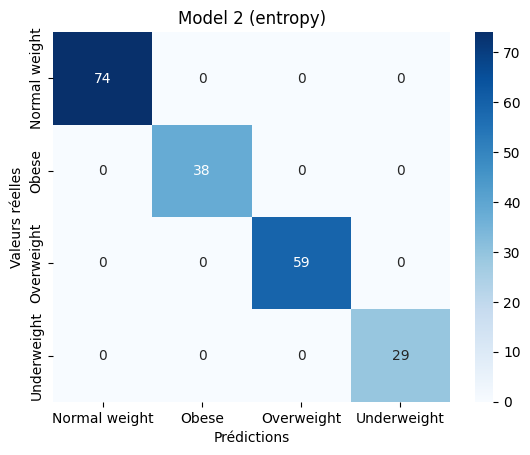

In [15]:
evaluate(model2, X_train, y_train, X_test, y_test, "Model 2 (entropy)")

<p>Mêmes métriques que le modèle 1. Normal : on voit en Q14 que les deux arbres sont exactement les mêmes.</p>

<h3>Partie 7 :</h3><h4>13. Affichage des arbres</h4>

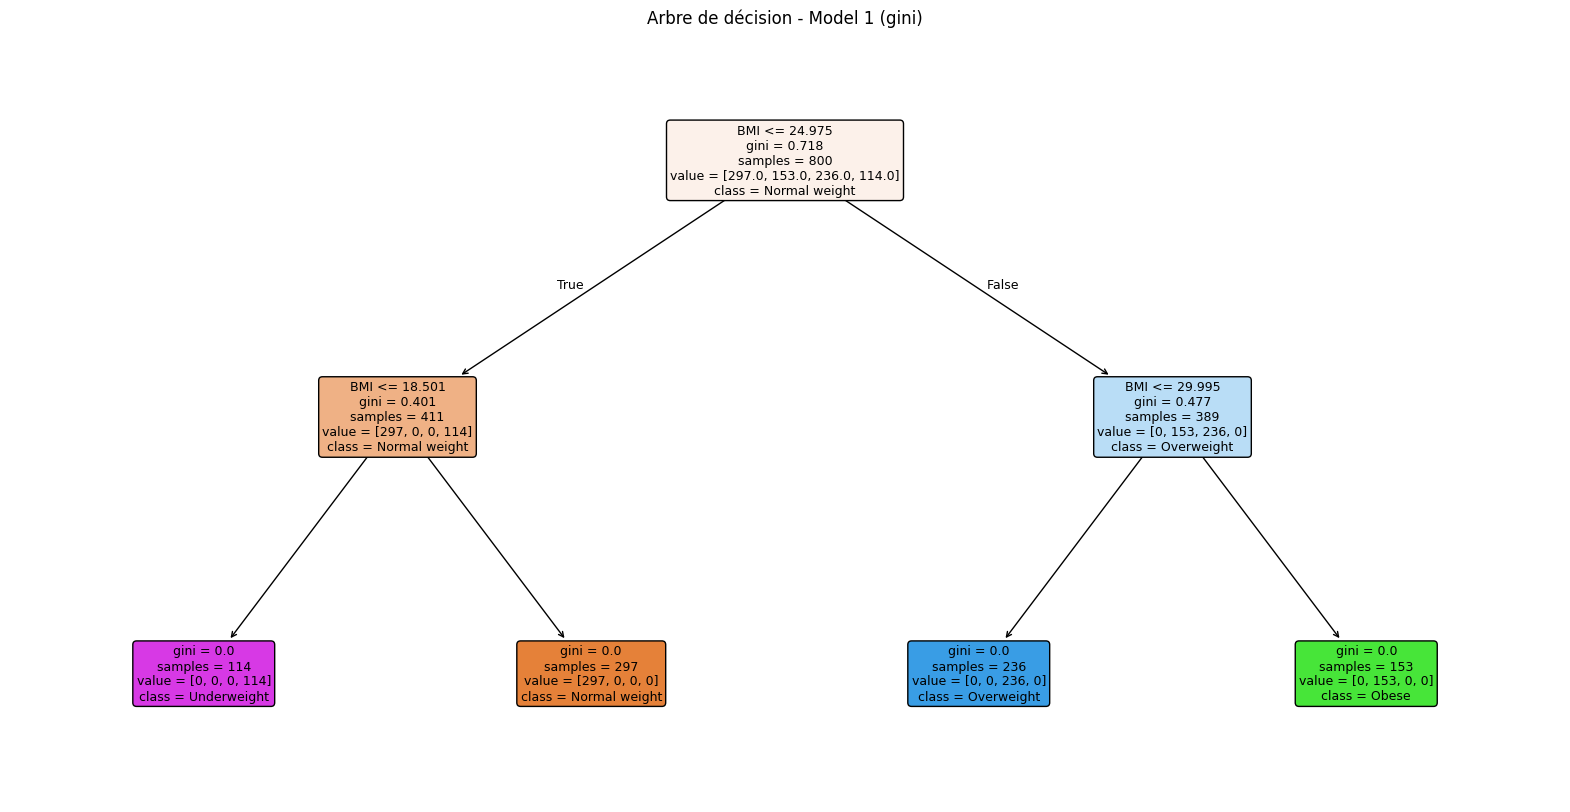

In [16]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(model1, feature_names=X.columns, class_names=model1.classes_,
          filled=True, rounded=True, fontsize=9)
plt.title("Arbre de décision - Model 1 (gini)")
plt.show()

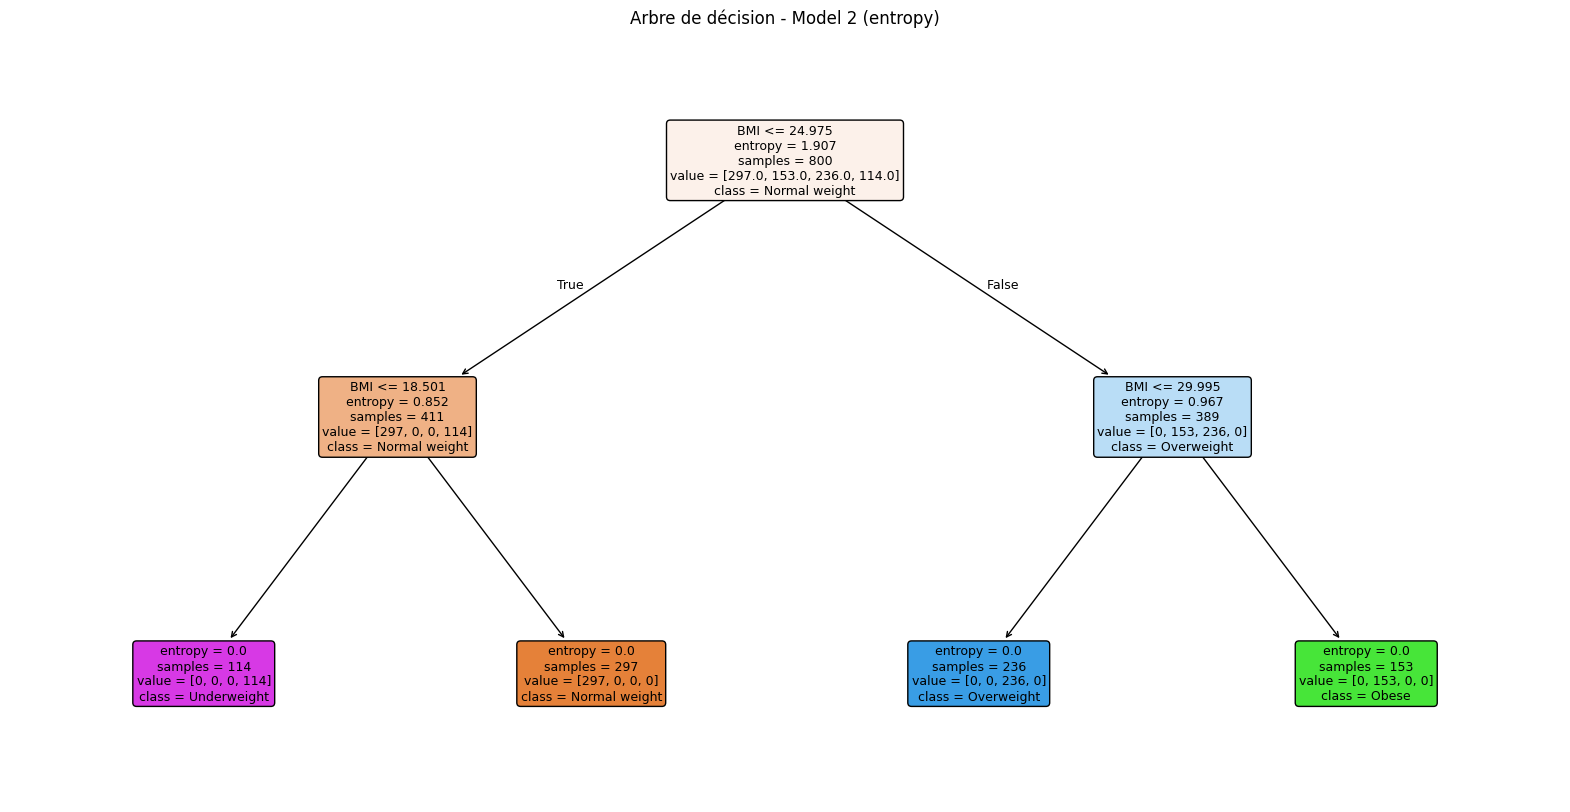

In [17]:
plt.figure(figsize=(20, 10))
plot_tree(model2, feature_names=X.columns, class_names=model2.classes_,
          filled=True, rounded=True, fontsize=9)
plt.title("Arbre de décision - Model 2 (entropy)")
plt.show()

<h4>14. Interprétabilité</h4>

In [18]:
from sklearn.tree import export_text

txt1 = export_text(model1, feature_names=list(X.columns))
txt2 = export_text(model2, feature_names=list(X.columns))
print(txt1)
print("Model 1 (gini)    : profondeur", model1.get_depth(), "| feuilles", model1.get_n_leaves())
print("Model 2 (entropy) : profondeur", model2.get_depth(), "| feuilles", model2.get_n_leaves())
print("Arbres identiques (structure, variables et seuils) :", txt1 == txt2)

|--- BMI <= 24.97
|   |--- BMI <= 18.50
|   |   |--- class: Underweight
|   |--- BMI >  18.50
|   |   |--- class: Normal weight
|--- BMI >  24.97
|   |--- BMI <= 30.00
|   |   |--- class: Overweight
|   |--- BMI >  30.00
|   |   |--- class: Obese

Model 1 (gini)    : profondeur 2 | feuilles 4
Model 2 (entropy) : profondeur 2 | feuilles 4
Arbres identiques (structure, variables et seuils) : True


<p>Les deux arbres sont identiques (profondeur 2, 4 feuilles, 3 tests sur le BMI). Ils sont donc autant interprétables l'un que l'autre, et très lisibles : on retrouve directement les classes de l'OMS.</p>
<p>Ils sont identiques parce que le BMI sépare parfaitement les 4 classes, donc Gini et entropie trouvent les mêmes seuils. C'est propre à ce dataset : en général les deux critères peuvent donner des arbres différents (voir le complément). Et des métriques identiques ne suffisent pas pour dire que deux arbres sont identiques, il faut comparer leur structure, ce qu'on fait ici.</p>

<h3>Complément : sans BMI</h3>
<p>On garde Height et Weight à la place du BMI, pour voir ce que donne le modèle sans fuite.</p>

In [19]:
df_nb = df_raw.copy()
df_nb["Gender"] = df_nb["Gender"].map({"Male": 0, "Female": 1})
X_nb = df_nb[["Age", "Gender", "Height", "Weight", "PhysicalActivityLevel"]]
Y_nb = df_nb["ObesityCategory"]
Xn_tr, Xn_te, yn_tr, yn_te = train_test_split(X_nb, Y_nb, train_size=0.8, test_size=0.2,
                                              random_state=SEED, stratify=Y_nb)

m_gini = DecisionTreeClassifier(random_state=SEED).fit(Xn_tr, yn_tr)
m_ent = DecisionTreeClassifier(criterion="entropy", random_state=SEED).fit(Xn_tr, yn_tr)
for name, m in [("gini", m_gini), ("entropy", m_ent)]:
    print(f"{name:8s} train={m.score(Xn_tr, yn_tr):.3f}  test={m.score(Xn_te, yn_te):.3f}  "
          f"profondeur={m.get_depth()}  feuilles={m.get_n_leaves()}")
print("Arbres identiques :", export_text(m_gini) == export_text(m_ent))

gini     train=1.000  test=0.915  profondeur=10  feuilles=60
entropy  train=1.000  test=0.945  profondeur=11  feuilles=52
Arbres identiques : False


<p>Là c'est beaucoup plus dur : train à 1,0 mais test à environ 0,92 (gini) et 0,95 (entropie), donc il y a vraiment du surapprentissage. Les arbres sont énormes (50 à 60 feuilles) et pas du tout lisibles, et ils sont différents selon le critère.</p>
<p>L'écart entre les deux critères (environ 6 individus sur 200) est trop petit pour conclure avec un seul découpage. Pour améliorer : limiter la profondeur (max_depth) ou élaguer (ccp_alpha).</p>

<h1>Section 2 : ID3 from scratch</h1>

<h4>15. Chargement des données</h4>

In [20]:
df2 = pd.read_csv("Data_M2_TP1_MKokou/obesity_binary.csv")
print(df2.shape)
print(df2)

(8, 7)
   Age  Gender  Height  Weight  BMI  PhysicalActivityLevel  ObesityCategory
0    0       0       1       0    0                      1                0
1    1       1       0       1    1                      0                1
2    0       1       1       1    1                      0                1
3    1       0       1       1    1                      0                1
4    1       1       0       0    0                      1                0
5    0       0       0       1    1                      1                1
6    0       1       1       0    0                      1                0
7    1       0       0       1    1                      0                1


<h4>16. Choix de la racine</h4>

In [21]:
target = "ObesityCategory"
features = [c for c in df2.columns if c != target]

def entropy(series):
    """Entropie de Shannon (base 2) d'une série de classes."""
    probs = series.value_counts() / len(series)
    return -sum(p * np.log2(p) for p in probs if p > 0)

def information_gain(df, feature, target):
    """Gain d'information = H(cible) - H(cible | attribut)."""
    weighted = sum(len(g) / len(df) * entropy(g[target]) for _, g in df.groupby(feature))
    return entropy(df[target]) - weighted

gains = {f: information_gain(df2, f, target) for f in features}
for feat, gain in gains.items():
    print(f"{feat:25s} -> Gain = {gain:.4f}")

best = max(gains.values())
ties = [f for f, g in gains.items() if np.isclose(g, best)]
root_attribute = ties[0]
print(f"\nGain maximal = {best:.4f}, atteint par : {ties}")
print(f">>> Attribut retenu pour la racine : {root_attribute}")

Age                       -> Gain = 0.0488
Gender                    -> Gain = 0.0488
Height                    -> Gain = 0.0488
Weight                    -> Gain = 0.9544
BMI                       -> Gain = 0.9544
PhysicalActivityLevel     -> Gain = 0.5488

Gain maximal = 0.9544, atteint par : ['Weight', 'BMI']
>>> Attribut retenu pour la racine : Weight


<p>L'entropie de départ vaut 0,9544 (5 exemples de classe 1 et 3 de classe 0). Weight et BMI ont tous les deux le gain maximum, car dans ce tableau ces deux colonnes sont identiques à la cible. Il y a égalité, et on prend Weight simplement parce qu'il vient avant dans les colonnes. BMI donnerait le même arbre.</p>

<h4>17. Construction et visualisation de l'arbre</h4>

In [22]:
def id3(df, target, features):
    """Construit récursivement un arbre ID3 (dictionnaire imbriqué {attribut: {valeur: sous-arbre}})."""
    labels = df[target].unique()
    if len(labels) == 1:                       # feuille pure
        return int(labels[0])
    if len(features) == 0:                     # plus d'attribut : classe majoritaire
        return int(df[target].mode()[0])
    gains = {f: information_gain(df, f, target) for f in features}
    best_feat = max(gains, key=gains.get)
    remaining = [f for f in features if f != best_feat]
    return {best_feat: {int(val): id3(group, target, remaining)
                        for val, group in df.groupby(best_feat)}}

def print_tree(tree, depth=0):
    """Affichage texte indenté."""
    if not isinstance(tree, dict):
        print("  " * depth + f"-> class: {tree}")
        return
    for feat, branches in tree.items():
        for val, sub in branches.items():
            print("  " * depth + f"[{feat} = {val}]")
            print_tree(sub, depth + 1)

tree = id3(df2, target, features)
print_tree(tree)

[Weight = 0]
  -> class: 0
[Weight = 1]
  -> class: 1


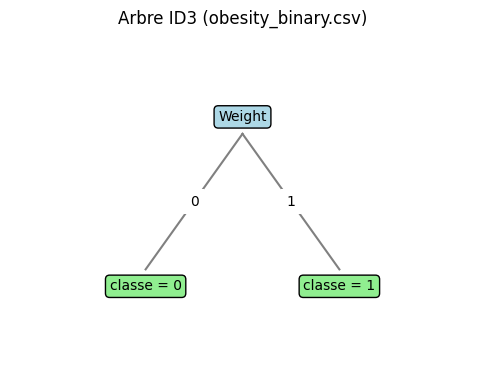

In [23]:
def tree_depth(tree):
    """Profondeur = nombre d'arêtes du plus long chemin racine -> feuille."""
    if not isinstance(tree, dict):
        return 0
    return 1 + max(tree_depth(sub) for br in tree.values() for sub in br.values())

def count_leaves(tree):
    if not isinstance(tree, dict):
        return 1
    return sum(count_leaves(sub) for br in tree.values() for sub in br.values())

def plot_tree_generic(tree, title="Arbre de décision"):
    """Dessine un arbre imbriqué de profondeur quelconque (feuilles alignées sur l'axe x)."""
    positions, counter = {}, [0]

    def layout(node, depth, path):
        if not isinstance(node, dict):
            positions[path] = (counter[0], -depth); counter[0] += 1
            return positions[path][0]
        xs = []
        for feat, br in node.items():
            for val, sub in br.items():
                xs.append(layout(sub, depth + 1, path + ((feat, val),)))
        positions[path] = (sum(xs) / len(xs), -depth)
        return positions[path][0]

    layout(tree, 0, ())

    fig, ax = plt.subplots(figsize=(max(6, 2.2 * count_leaves(tree)), 2.2 * (tree_depth(tree) + 1)))

    def draw(node, path):
        x, y = positions[path]
        if not isinstance(node, dict):
            ax.text(x, y, f"classe = {node}", ha="center", va="center",
                    bbox=dict(boxstyle="round", facecolor="lightgreen"))
            return
        feat = list(node.keys())[0]
        ax.text(x, y, feat, ha="center", va="center", bbox=dict(boxstyle="round", facecolor="lightblue"))
        for val, sub in node[feat].items():
            cpath = path + ((feat, val),)
            cx, cy = positions[cpath]
            ax.plot([x, cx], [y - 0.1, cy + 0.1], color="gray", zorder=0)
            ax.text((x + cx) / 2, (y + cy) / 2, str(val), ha="center", va="center",
                    bbox=dict(facecolor="white", edgecolor="none"))
            draw(sub, cpath)

    draw(tree, ())
    ax.set_xlim(-0.7, counter[0] - 0.3); ax.set_ylim(-tree_depth(tree) - 0.5, 0.5)
    ax.axis("off"); ax.set_title(title)
    plt.show()

plot_tree_generic(tree, "Arbre ID3 (obesity_binary.csv)")

<h4>18. Profondeur maximale</h4>

In [24]:
print("Profondeur maximale (ID3) :", tree_depth(tree))

Profondeur maximale (ID3) : 1


<p>La profondeur maximale est 1 : un seul test suffit, car Weight sépare parfaitement les classes.</p>

<h4>19. Nombre de feuilles</h4>

In [25]:
print("Nombre de feuilles (ID3) :", count_leaves(tree))

Nombre de feuilles (ID3) : 2


<p>Il y a 2 feuilles, une par valeur de Weight (classe 0 et classe 1).</p>

<h1>Section 3 : C4.5</h1>
<h4>20. Refaire la Section 2 avec C4.5</h4>

<p>C4.5 remplace le gain d'information par le ratio de gain : Gain / SplitInfo, où SplitInfo est l'entropie de la répartition des exemples selon l'attribut. Ça évite de favoriser les attributs qui ont beaucoup de valeurs (un identifiant, par exemple).</p>

In [26]:
def split_info(df, feature):
    """Entropie de la répartition des exemples selon l'attribut."""
    probs = df[feature].value_counts() / len(df)
    return -sum(p * np.log2(p) for p in probs if p > 0)

def gain_ratio(df, feature, target):
    si = split_info(df, feature)
    return 0 if si == 0 else information_gain(df, feature, target) / si

def c45(df, target, features):
    """C4.5 simplifié : même structure qu'ID3, critère = ratio de gain."""
    labels = df[target].unique()
    if len(labels) == 1:
        return int(labels[0])
    if len(features) == 0:
        return int(df[target].mode()[0])
    ratios = {f: gain_ratio(df, f, target) for f in features}
    best_feat = max(ratios, key=ratios.get)
    remaining = [f for f in features if f != best_feat]
    return {best_feat: {int(val): c45(group, target, remaining)
                        for val, group in df.groupby(best_feat)}}

ratios = {f: gain_ratio(df2, f, target) for f in features}
for feat, r in ratios.items():
    print(f"{feat:25s} -> Gain ratio = {r:.4f}")

tree_c45 = c45(df2, target, features)
print()
print_tree(tree_c45)
print("Profondeur :", tree_depth(tree_c45), "| feuilles :", count_leaves(tree_c45))
print("Même arbre qu'ID3 :", tree_c45 == tree)

Age                       -> Gain ratio = 0.0488
Gender                    -> Gain ratio = 0.0488
Height                    -> Gain ratio = 0.0488
Weight                    -> Gain ratio = 1.0000
BMI                       -> Gain ratio = 1.0000
PhysicalActivityLevel     -> Gain ratio = 0.5488

[Weight = 0]
  -> class: 0
[Weight = 1]
  -> class: 1
Profondeur : 1 | feuilles : 2
Même arbre qu'ID3 : True


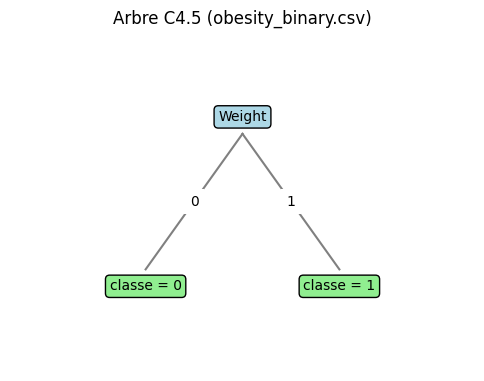

In [27]:
plot_tree_generic(tree_c45, "Arbre C4.5 (obesity_binary.csv)")

<p>La racine est encore Weight (ratio de gain = 1, à égalité avec BMI), profondeur 1 et 2 feuilles : l'arbre est identique à celui d'ID3. Ça s'explique parce qu'un seul attribut sépare parfaitement les classes, donc la normalisation ne change rien au classement.</p>
<p>Mon implémentation ne reprend que le ratio de gain. Le vrai C4.5 gère aussi les attributs continus, les valeurs manquantes et l'élagage, mais ici les données sont binaires et complètes, donc ça ne sert pas.</p>